In [3]:
# ==========================================
# CROP YIELD DATASET ANALYSIS + ML PROJECT
# ==========================================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Optional: make plots look cleaner
sns.set_theme(style="whitegrid")

Matplotlib is building the font cache; this may take a moment.


In [4]:
# Load dataset
df = pd.read_csv("crop_yield.csv")

# Number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# First 10 records
print("\nFirst 10 Records:")
display(df.head(10))
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")
print("Columns are:", ", ".join(df.columns))

Number of rows: 1500
Number of columns: 8

Column Names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 Records:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


The dataset has 1500 rows and 8 columns.
Columns are: rainfall_mm, temperature_c, fertilizer_kg, irrigation_hours, soil_ph, crop_type, soil_type, yield_ton_per_hectare


In [5]:
# Data types
print("Data Types:")
print(df.dtypes)

# Missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())

# Columns with missing values
missing_columns = df.columns[df.isnull().any()].tolist()

if missing_columns:
    print("\nColumns with missing values:", missing_columns)
else:
    print("\nNo missing values are present in the dataset.")

Data Types:
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                    str
soil_type                    str
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

No missing values are present in the dataset.


In [6]:
# Summary statistics for numerical columns
numerical_summary = df.describe()
display(numerical_summary)

# Mean of numerical features
mean_values = df.select_dtypes(include=np.number).mean()

# Standard deviation of numerical features
std_values = df.select_dtypes(include=np.number).std()

# Feature with highest mean
highest_mean_feature = mean_values.idxmax()
highest_mean_value = mean_values.max()

# Feature with highest standard deviation
highest_std_feature = std_values.idxmax()
highest_std_value = std_values.max()

print("Feature with highest mean:", highest_mean_feature)
print("Highest mean value:", highest_mean_value)

print("\nFeature with highest standard deviation:", highest_std_feature)
print("Highest standard deviation value:", highest_std_value)

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


Feature with highest mean: rainfall_mm
Highest mean value: 754.0546666666667

Feature with highest standard deviation: rainfall_mm
Highest standard deviation value: 255.09721614450967


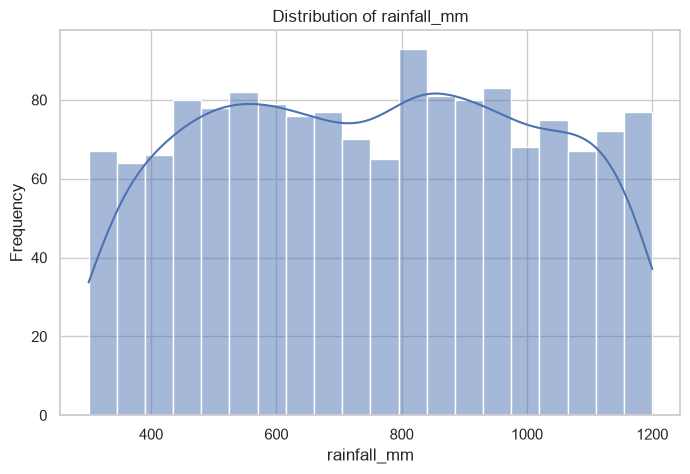

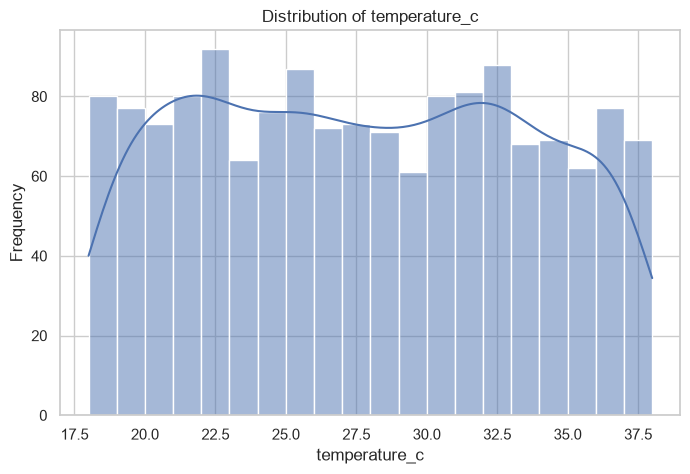

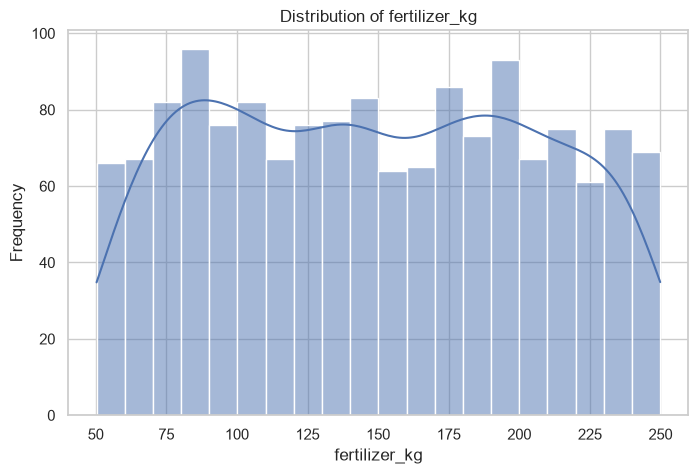

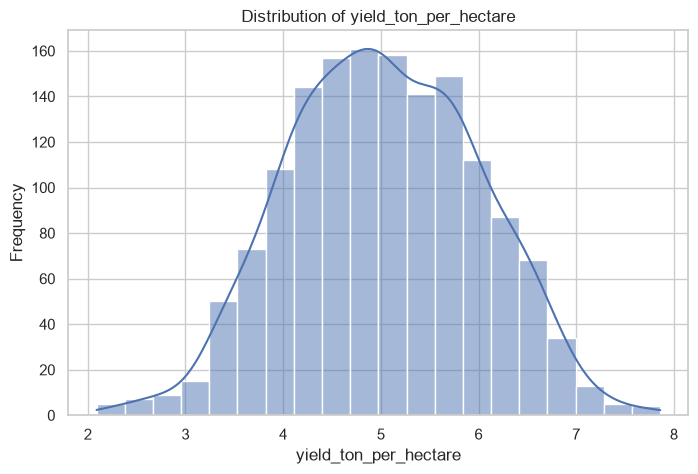

In [7]:
features = [
    "rainfall_mm",
    "temperature_c",
    "fertilizer_kg",
    "yield_ton_per_hectare"
]

for feature in features:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[feature], bins=20, kde=True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

Crop Type Counts:
crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


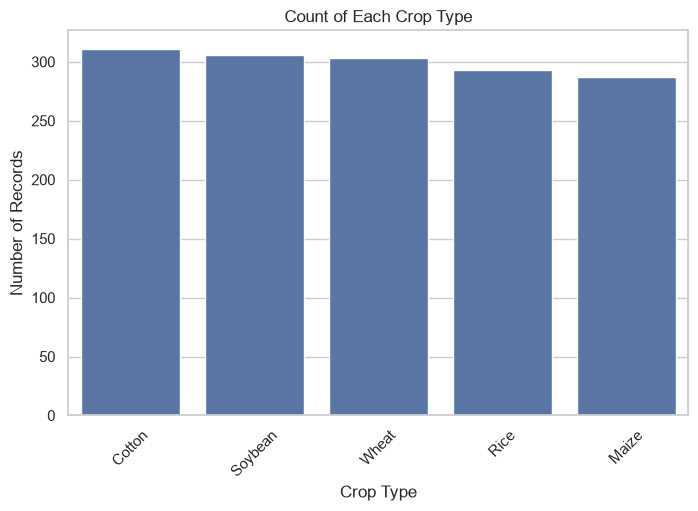

Most frequent crop type: Cotton


In [8]:
# Count records for each crop type
crop_counts = df["crop_type"].value_counts()

print("Crop Type Counts:")
print(crop_counts)

# Count plot
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="crop_type", order=df["crop_type"].value_counts().index)
plt.title("Count of Each Crop Type")
plt.xlabel("Crop Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

# Most frequent crop
most_frequent_crop = df["crop_type"].value_counts().idxmax()

print("Most frequent crop type:", most_frequent_crop)

Soil Type Counts:
soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


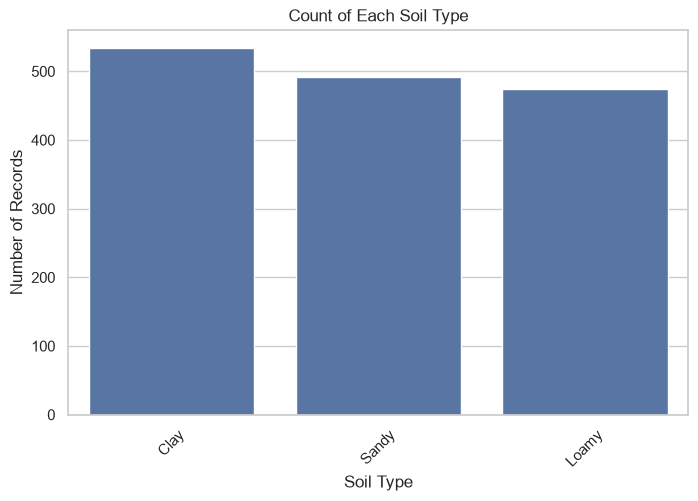

Most common soil type: Clay


In [9]:
# Frequency of soil types
soil_counts = df["soil_type"].value_counts()

print("Soil Type Counts:")
print(soil_counts)

# Count plot
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="soil_type", order=df["soil_type"].value_counts().index)
plt.title("Count of Each Soil Type")
plt.xlabel("Soil Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

# Most common soil type
most_common_soil = df["soil_type"].value_counts().idxmax()

print("Most common soil type:", most_common_soil)

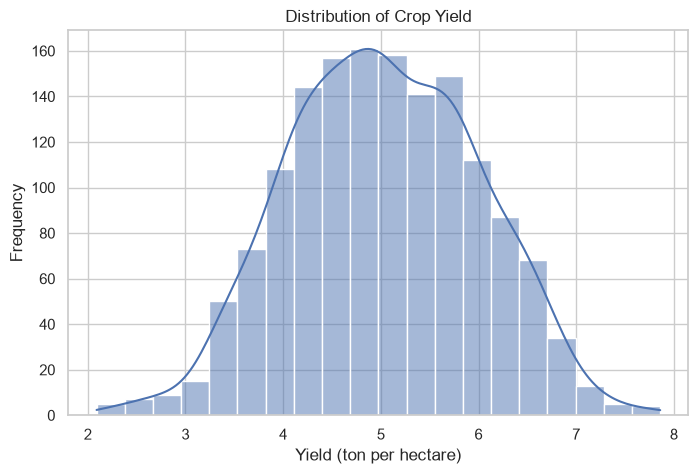

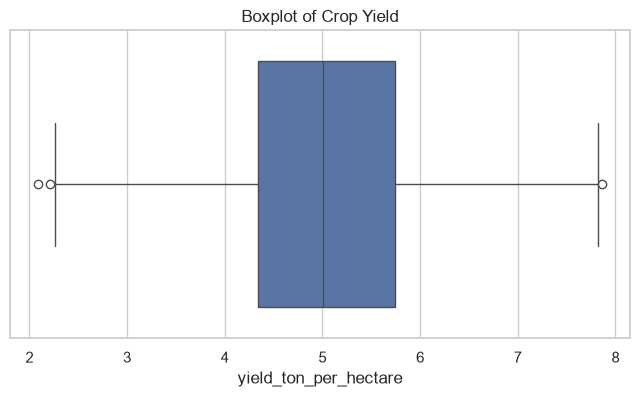

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df["yield_ton_per_hectare"], bins=20, kde=True)
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (ton per hectare)")
plt.ylabel("Frequency")
plt.show()

# Boxplot for identifying outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["yield_ton_per_hectare"])
plt.title("Boxplot of Crop Yield")
plt.show()

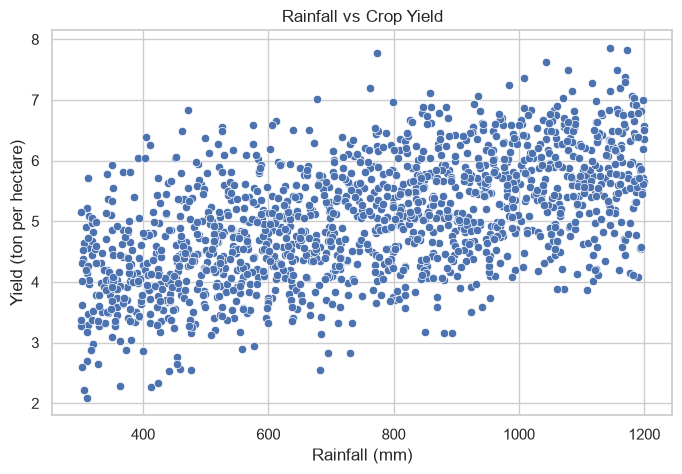

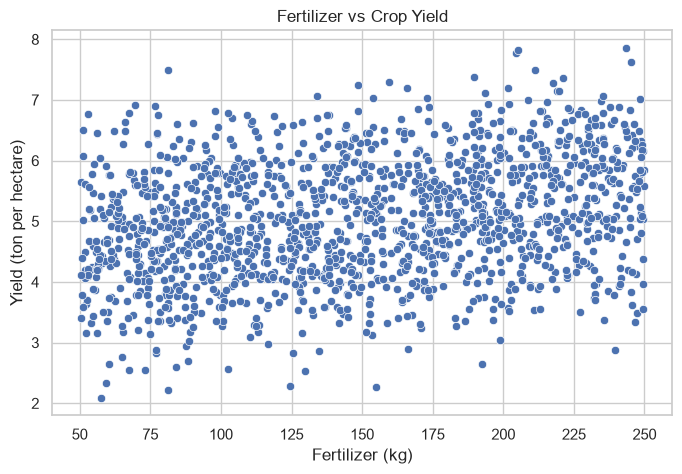

In [11]:
# Rainfall vs Yield
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="rainfall_mm", y="yield_ton_per_hectare")
plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (ton per hectare)")
plt.show()

# Fertilizer vs Yield
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="fertilizer_kg", y="yield_ton_per_hectare")
plt.title("Fertilizer vs Crop Yield")
plt.xlabel("Fertilizer (kg)")
plt.ylabel("Yield (ton per hectare)")
plt.show()

In [12]:
rainfall_corr = df["rainfall_mm"].corr(df["yield_ton_per_hectare"])
fertilizer_corr = df["fertilizer_kg"].corr(df["yield_ton_per_hectare"])

print("Rainfall-Yield Correlation:", rainfall_corr)
print("Fertilizer-Yield Correlation:", fertilizer_corr)

if abs(rainfall_corr) > abs(fertilizer_corr):
    print("Rainfall appears to have a stronger relationship with yield.")
else:
    print("Fertilizer appears to have a stronger relationship with yield.")

Rainfall-Yield Correlation: 0.5537042408932247
Fertilizer-Yield Correlation: 0.27804258886930483
Rainfall appears to have a stronger relationship with yield.


Correlation Matrix:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
rainfall_mm,1.000000,0.026721,0.002558,0.010877,0.006916,0.553704
temperature_c,0.026721,1.000000,0.037468,0.007114,0.001513,-0.022559
fertilizer_kg,0.002558,0.037468,1.000000,-0.010497,0.010001,0.278043
irrigation_hours,0.010877,0.007114,-0.010497,1.000000,0.009307,0.542664
soil_ph,0.006916,0.001513,0.010001,0.009307,1.000000,0.024412
yield_ton_per_hectare,0.553704,-0.022559,0.278043,0.542664,0.024412,1.000000


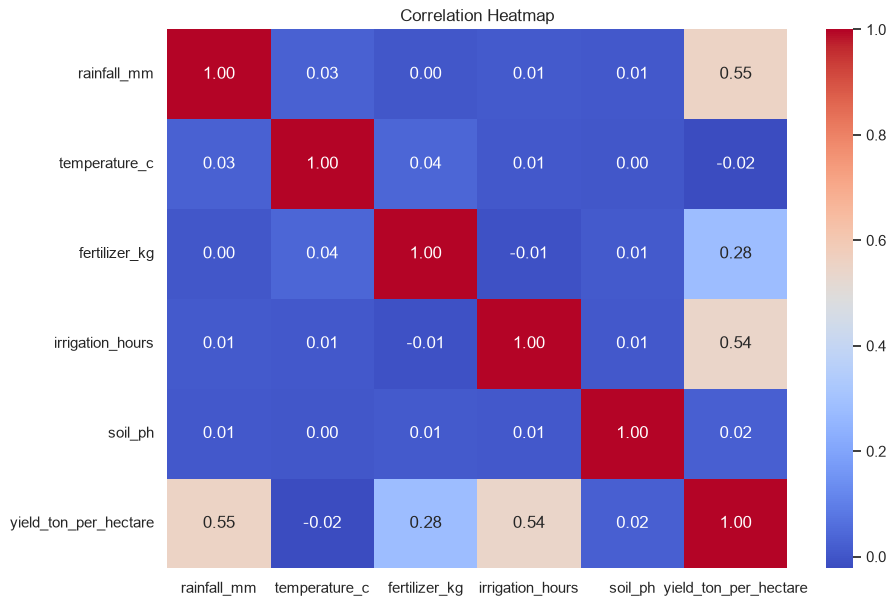

Correlation with Yield:
yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64

Top 3 Features Most Correlated With Yield:
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


In [13]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=np.number)

# Correlation matrix
correlation_matrix = numeric_df.corr()

print("Correlation Matrix:")
display(correlation_matrix)

# Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Correlation with yield
yield_correlation = correlation_matrix["yield_ton_per_hectare"].sort_values(
    ascending=False
)

print("Correlation with Yield:")
print(yield_correlation)

# Top three features correlated with yield
top_3_features = (
    yield_correlation
    .drop("yield_ton_per_hectare")
    .abs()
    .sort_values(ascending=False)
    .head(3)
)

print("\nTop 3 Features Most Correlated With Yield:")
print(top_3_features)

In [14]:
# Average yield by crop type
average_yield_crop = df.groupby("crop_type")["yield_ton_per_hectare"].mean()

print("Average Yield by Crop Type:")
print(average_yield_crop)

# Average yield by soil type
average_yield_soil = df.groupby("soil_type")["yield_ton_per_hectare"].mean()

print("\nAverage Yield by Soil Type:")
print(average_yield_soil)

# Highest average yield crop
best_crop = average_yield_crop.idxmax()
best_crop_yield = average_yield_crop.max()

# Highest average yield soil
best_soil = average_yield_soil.idxmax()
best_soil_yield = average_yield_soil.max()

print("\nCrop with highest average yield:", best_crop)
print("Average yield:", best_crop_yield)

print("\nSoil type with highest average yield:", best_soil)
print("Average yield:", best_soil_yield)

Average Yield by Crop Type:
crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Average Yield by Soil Type:
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Crop with highest average yield: Rice
Average yield: 5.494744027303755

Soil type with highest average yield: Loamy
Average yield: 5.366518987341772


In [15]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

# One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

# Display first 5 rows
print("First 5 Rows of Encoded Dataset:")
display(df_encoded.head())

Categorical Columns:
['crop_type', 'soil_type']
First 5 Rows of Encoded Dataset:


C:\Users\Agrima\AppData\Local\Temp\ipykernel_15724\598734863.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


In [16]:
# Target variable
target_column = "yield_ton_per_hectare"

# Input features
X = df_encoded.drop(columns=[target_column])

# Target variable
y = df_encoded[target_column]

print("Target Variable:", target_column)

print("\nInput Features:")
print(X.columns.tolist())

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Target Variable: yield_ton_per_hectare

Input Features:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type_Maize', 'crop_type_Rice', 'crop_type_Soybean', 'crop_type_Wheat', 'soil_type_Loamy', 'soil_type_Sandy']

Shape of X: (1500, 11)
Shape of y: (1500,)


In [17]:
# Split dataset into 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1200, 11)
X_test shape: (300, 11)
y_train shape: (1200,)
y_test shape: (300,)


In [18]:
# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Model coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

# Sort coefficients from highest to lowest
coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

print("Model Intercept:")
print(model.intercept_)

print("\nModel Coefficients:")
display(coefficients)

# Feature with highest positive coefficient
highest_positive_feature = coefficients.iloc[0]

print("Feature with highest positive coefficient:")
print(highest_positive_feature["Feature"])

print("Coefficient value:")
print(highest_positive_feature["Coefficient"])

Model Intercept:
1.587132027736125

Model Coefficients:


,Feature,Coefficient
6,crop_type_Rice,0.863993
7,crop_type_Soybean,0.481719
8,crop_type_Wheat,0.348474
9,soil_type_Loamy,0.302974
5,crop_type_Maize,0.238931
3,irrigation_hours,0.198327
2,fertilizer_kg,0.004978
4,soil_ph,0.004901
0,rainfall_mm,0.002035
1,temperature_c,-0.009175


Feature with highest positive coefficient:
crop_type_Rice
Coefficient value:
0.8639928397012276


In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn

  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 2.1 MB/s eta 0:00:05
   ---- ----------------------------------- 1.0/9.8 MB 2.2 MB/s eta 0:00:04
   ------- -------------------------------- 1.8/9.8 MB 2.4 MB/s eta 0:00:04
   --------- ------------------------------ 2.4/9.8 MB 2.6 MB/s eta 0:00:03
   ------------ ---------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
